# harmony对项目数据着整合

In [2]:
##系统报错改为英文
Sys.setenv(LANGUAGE = "en")
##禁止转化为因子
options(stringsAsFactors = FALSE)
##清空环境
rm(list=ls())

setwd("/Users/a1-6/Documents/projects/DL/97-bioinformatics/gene_process_for_python/single-cell-rna")
###加载所需要的包
library(Seurat)
library(tidyverse)
library(dplyr)
library(patchwork)
library(harmony)


In [35]:
scRNA.11=Read10X("data/GSE152048/BC2/")
scRNA.3=Read10X("data/GSE152048/BC21/")
scRNA.11 = CreateSeuratObject(scRNA.11 ,project="sample_11", min.cells = 3, min.features = 200)
scRNA.3 = CreateSeuratObject(scRNA.3 ,project="sample_3", min.cells = 3, min.features = 200)

scRNA_harmony <- merge(scRNA.11, y=c(scRNA.3 ))
scRNA_harmony <- NormalizeData(scRNA_harmony, normalization.method = "LogNormalize", scale.factor = 1e4) %>% FindVariableFeatures() %>% ScaleData() %>% RunPCA(verbose=FALSE)
#### harmony的整合是基于PCA结果数据
system.time({scRNA_harmony <- RunHarmony(scRNA_harmony, group.by.vars = "orig.ident")})

Centering and scaling data matrix

Transposing data matrix

Initializing state using k-means centroids initialization

Harmony 1/10

Harmony 2/10

Harmony 3/10

Harmony 4/10

Harmony 5/10

Harmony 6/10

Harmony converged after 6 iterations



   user  system elapsed 
  3.289   0.596   3.598 

In [4]:
scRNA_harmony@meta.data

,orig.ident,nCount_RNA,nFeature_RNA
,<chr>,<dbl>,<int>
AAACCTGAGATCCCGC-1,sample_11,1227,620
AAACCTGCAGGAATCG-1,sample_11,1180,670
AAACCTGGTACACCGC-1,sample_11,825,450
AAACCTGGTACGCACC-1,sample_11,1618,788
AAACCTGGTAGAAGGA-1,sample_11,1032,610
AAACCTGGTCGCGTGT-1,sample_11,1017,472
AAACCTGGTGCAGTAG-1,sample_11,1085,538
AAACCTGGTTAGTGGG-1,sample_11,734,417
AAACCTGGTTCCACTC-1,sample_11,890,520


In [5]:
str(scRNA_harmony)

Formal class 'Seurat' [package "SeuratObject"] with 13 slots
  ..@ assays      :List of 1
  .. ..$ RNA:Formal class 'Assay' [package "SeuratObject"] with 8 slots
  .. .. .. ..@ counts       :Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
  .. .. .. .. .. ..@ i       : int [1:19612596] 33 53 75 104 164 207 237 248 256 287 ...
  .. .. .. .. .. ..@ p       : int [1:12458] 0 620 1290 1740 2528 3138 3610 4148 4565 5085 ...
  .. .. .. .. .. ..@ Dim     : int [1:2] 20738 12457
  .. .. .. .. .. ..@ Dimnames:List of 2
  .. .. .. .. .. .. ..$ : chr [1:20738] "AL669831.5" "LINC00115" "FAM41C" "SAMD11" ...
  .. .. .. .. .. .. ..$ : chr [1:12457] "AAACCTGAGATCCCGC-1" "AAACCTGCAGGAATCG-1" "AAACCTGGTACACCGC-1" "AAACCTGGTACGCACC-1" ...
  .. .. .. .. .. ..@ x       : num [1:19612596] 1 1 1 1 1 1 1 3 1 3 ...
  .. .. .. .. .. ..@ factors : list()
  .. .. .. ..@ data         :Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
  .. .. .. .. .. ..@ i       : int [1:19612596] 33 53 75 104 164

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 12457
Number of edges: 444154

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9306
Number of communities: 14
Elapsed time: 0 seconds


15:13:29 UMAP embedding parameters a = 0.9922 b = 1.112

15:13:29 Read 12457 rows and found 16 numeric columns

15:13:29 Using Annoy for neighbor search, n_neighbors = 30

15:13:29 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

15:13:29 Writing NN index file to temp file /var/folders/9d/07pjf8p54vb0cjnyp1ql9j2m0000gn/T//RtmpHr92NT/file630e455c359f

15:13:29 Searching Annoy index using 1 thread, search_k = 3000

15:13:31 Annoy recall = 100%

15:13:31 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

15:13:32 Initializing from normalized Laplacian + noise (using irlba)

15:13:32 Commencing optimization for 200 epochs, with 534848 positive edges

15:13:32 Using rng type: pcg

15:13:36 Optimization finished



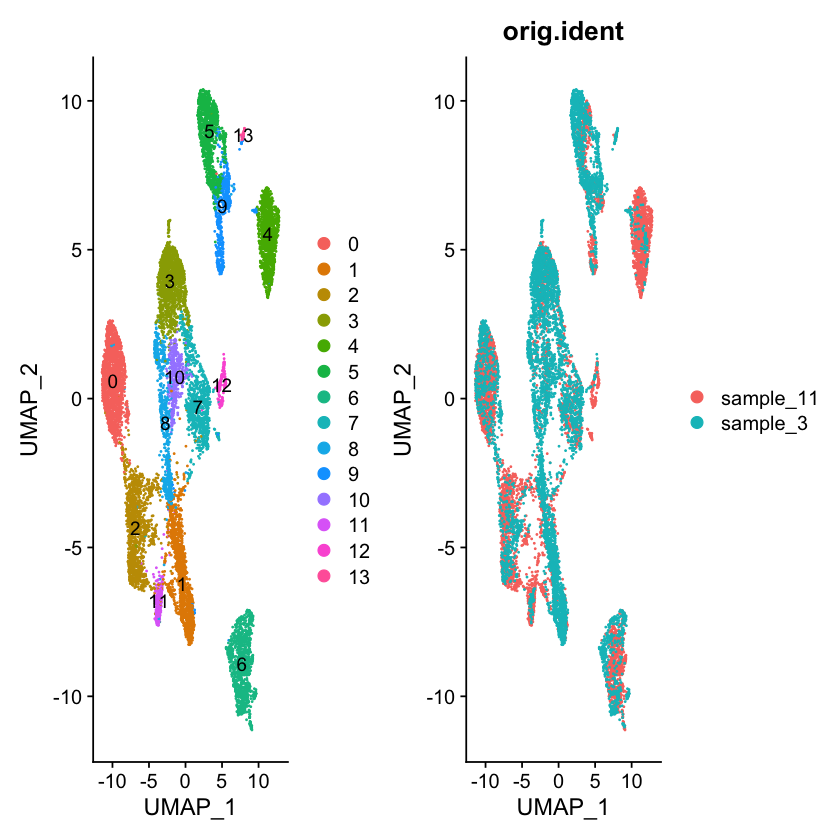

In [36]:
###问题 harmony之后的数据在哪里？


###一定要指定harmony
scRNA_harmony <- FindNeighbors(scRNA_harmony, 
                               reduction = "harmony", 
                               dims = 1:15) %>% FindClusters(resolution = 0.5)

scRNA_harmony <- RunUMAP(scRNA_harmony, reduction = "harmony", dims = 1:16)
# ?DimPlot
plot1 =DimPlot(scRNA_harmony, reduction = "umap",label = T) 
plot2 = DimPlot(scRNA_harmony, reduction = "umap", group.by='orig.ident') 
#combinate
plotc <- plot1+plot2
plotc

22:16:11 UMAP embedding parameters a = 0.9922 b = 1.112

22:16:11 Read 12457 rows and found 16 numeric columns

22:16:11 Using Annoy for neighbor search, n_neighbors = 30

22:16:11 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

22:16:12 Writing NN index file to temp file /var/folders/9d/07pjf8p54vb0cjnyp1ql9j2m0000gn/T//RtmpVWgAas/file157e411bdcaf

22:16:12 Searching Annoy index using 1 thread, search_k = 3000

22:16:14 Annoy recall = 100%

22:16:14 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

22:16:15 Initializing from normalized Laplacian + noise (using RSpectra)

22:16:15 Commencing optimization for 200 epochs, with 522990 positive edges

22:16:15 Using rng type: pcg

22:16:19 Optimization finished



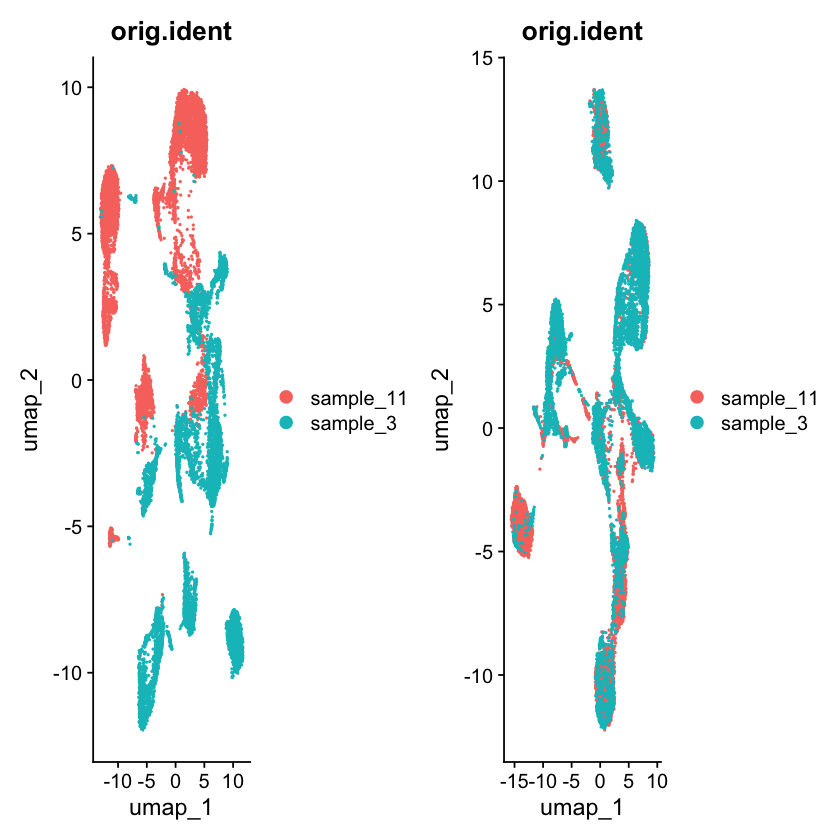

In [ ]:
#### 不整合数据查看对比

scRNA_harmony.1 <- RunUMAP(scRNA_harmony, reduction = "pca", dims = 1:16)
plot1 =DimPlot(scRNA_harmony.1, reduction = "umap",, group.by='orig.ident') 
plot2 = DimPlot(scRNA_harmony, reduction = "umap", group.by='orig.ident') 
#combinate
plotc <- plot1+plot2
plotc

In [7]:
scRNA_harmony@meta.data$seurat_clusters

[1] 3  4  2  0  6  2  2  0  0  0  2  2  0  11 5  2  4  1  2  0  6  4  3  11
   [25] 5  0  12 1  0  4  0  4  0  6  2  6  3  2  4  5  4  4  4  2  1  11 4  0 
   [49] 2  0  0  4  5  12 4  2  4  6  4  3  1  2  0  2  4  4  10 6  1  4  6  0 
   [73] 0  6  2  2  6  0  2  0  6  7  1  4  0  0  0  2  7  4  4  5  4  12 7  6 
   [97] 2  6  2  4  11 2  2  0  5  0  0  11 2  4  7  4  3  0  0  6  7  0  6  1 
  [121] 5  4  8  5  4  4  4  6  5  0  6  4  7  4  9  6  0  0  6  6  6  1  0  0 
  [145] 0  7  11 2  2  0  5  1  6  3  11 4  4  12 0  4  6  6  0  3  0  1  3  2 
  [169] 4  6  6  4  2  7  7  2  4  12 0  9  4  4  0  0  6  4  9  0  0  0  4  2 
  [193] 9  9  6  2  7  2  4  6  7  2  0  6  3  4  6  2  2  0  4  0  2  7  6  12
  [217] 6  11 0  2  2  4  5  1  6  6  0  2  3  12 2  0  9  9  1  2  1  2  1  0 
  [241] 3  5  6  2  6  5  6  0  4  2  0  4  7  1  6  2  5  4  5  12 6  5  8  0 
  [265] 6  6  4  6  7  11 6  9  5  3  3  2  12 1  6  2  4  1  4  1  9  5  2  9 
  [289] 6  6  5  3  2  7  4  0  0  4  6  2  4  4  4  5  7  3  7  12 11 7  3  1 
  [313] 4  0  4  2  2  7  0  0  5  6  3  11 2  1  2  6  1  6  0  6  2  0  2  6 
  [337] 6  2  0  2  0  8  9  3  1  2  2  11 5  4  6  1  2  4  9  12 1  2  2  6 
  [361] 2  2  0  3  12 7  2  3  0  2  4  4  12 7  7  6  7  0  4  0  1  1  0  0 
  [385] 6  9  6  4  0  10 7  0  6  11 4  2  2  2  5  4  2  0  4  9  4  4  7  2 
  [409] 2  2  7  5  0  3  12 4  4  5  0  9  6  6  11 1  0  2  4  5  3  4  6  5 
  [433] 0  11 2  0  5  0  8  4  0  4  0  4  0  13 4  6  0  3  0  1  7  10 11 2 
  [457] 5  8  6  2  6  2  0  2  0  4  0  7  4  12 4  0  2  6  4  0  9  2  2  6 
  [481] 0  4  0  7  0  6  2  4  0  6  2  7  2  0  6  4  0  0  6  0  7  6  2  4 
  [505] 1  3  2  3  4  4  3  0  1  5  6  0  4  8  6  2  4  6  3  5  4  4  2  0 
  [529] 6  0  0  7  0  0  6  3  4  1  0  0  4  11 0  0  2  8  0  12 9  6  4  1 
  [553] 0  2  4  6  0  7  4  11 4  1  11 6  0  12 1  4  2  0  4  2  2  2  2  2 
  [577] 2  6  0  2  5  6  2  11 1  4  6  11 3  2  1  4  2  5  2  1  2  4  8  6 
  [601] 6  4  5  2  2  7  8  2  3  4  2  3  4  0  5  6  6  7  4  5  10 0  2  1 
  [625] 4  4  8  4  2  3  2  0  1  0  2  4  0  6  4  0  0  3  4  2  4  4  0  1 
  [649] 0  12 12 5  4  9  2  2  7  6  12 1  4  4  0  2  6  0  7  0  0  8  6  0 
  [673] 2  2  4  3  11 4  1  9  3  3  1  0  4  4  9  7  2  4  1  5  0  2  3  6 
  [697] 4  2  6  0  11 2  0  7  0  10 6  7  2  4  4  2  0  2  2  2  9  0  5  2 
  [721] 10 0  3  1  7  1  6  4  0  0  0  2  0  6  7  6  0  4  0  4  5  2  10 4 
  [745] 2  4  0  2  2  6  0  2  0  6  6  10 6  0  4  2  9  1  4  2  5  4  11 9 
  [769] 1  4  0  1  0  11 2  12 1  2  2  2  6  4  6  7  4  0  7  3  0  3  1  2 
  [793] 11 2  4  6  0  5  5  4  2  0  7  9  4  6  3  6  3  7  2  9  0  3  7  4 
  [817] 4  4  7  2  7  3  0  5  0  0  9  4  2  2  6  3  0  4  6  2  2  2  4  0 
  [841] 6  0  4  6  6  0  5  4  4  4  0  0  3  2  0  5  2  1  4  2  1  10 6  4 
  [865] 7  3  2  0  0  2  0  11 11 1  4  0  6  4  0  4  5  0  6  4  0  1  5  0 
  [889] 1  6  0  0  4  2  0  1  0  0  2  0  12 0  2  4  0  2  9  4  6  2  0  4 
  [913] 0  12 4  6  2  0  10 6  6  6  0  0  4  2  2  5  0  9  0  2  5  2  4  4 
  [937] 3  4  2  6  2  0  4  0  6  4  9  2  0  8  5  1  4  0  0  1  4  0  0  12
  [961] 2  0  0  6  11 0  2  5  4  1  8  2  4  2  7  0  11 11 4  2  1  2  4  3 
  [985] 2  6  0  6  5  5  4  5  2  3  4  0  2  5  0  2  0  0  0  7  0  0  2  5 
 [1009] 4  0  9  8  6  6  4  0  4  4  4  4  4  0  0  5  0  0  4  0  7  3  0  0 
 [1033] 4  2  1  8  0  6  7  5  7  2  2  0  9  3  0  2  9  0  2  8  0  4  4  6 
 [1057] 6  9  4  4  0  9  2  5  2  2  0  9  0  4  4  7  0  2  2  1  11 0  2  11
 [1081] 0  2  4  7  12 2  0  4  8  12 0  6  2  2  0  2  6  4  1  6  6  4  7  1 
 [1105] 6  6  4  2  3  5  6  0  2  3  4  7  4  4  2  0  0  7  0  9  0  4  6  1 
 [1129] 6  2  0  6  6  0  2  12 4  7  0  2  2  2  0  4  8  4  7  4  2  5  6  4 
 [1153] 2  4  0  3  0  5  5  6  7  6  4  2  4  4  0  3  2  11 4  2  4  3  1  12
 [1177] 0  6  2  4  0  2  0  4  6  0  4  12 11 4  11 9  0  0  5  6  3  0  2  0 
 [12

In [37]:
#############
markers <- FindAllMarkers(object = scRNA_harmony, 
                         test.use="wilcox" ,
                         only.pos = TRUE,
                         logfc.threshold = 0.25,      # 降低logFC阈值
                         #min.pct = 0.1,              # 基因至少在10%的细胞中表达
                         #min.diff.pct = 0.001,        # 群间表达比例最小差异
                         #verbose = TRUE              # 打印运行日志
                            )  

Calculating cluster 0

Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5

Calculating cluster 6

Calculating cluster 7

Calculating cluster 8

Calculating cluster 9

Calculating cluster 10

Calculating cluster 11

Calculating cluster 12

Calculating cluster 13



In [38]:
scRNA_harmony@assays$RNA

Assay data with 20738 features for 12457 cells
Top 10 variable features:
 SFRP2, CXCL14, IBSP, FABP4, FCGBP, HBB, JCHAIN, CCL17, MT1G, WISP2 

In [ ]:
### V5结构需要
## scRNA_harmony <- JoinLayers(scRNA_harmony)

Calculating cluster sample_11

Calculating cluster sample_3

Warning message:
"No DE genes identified"
Warning message:
"The following tests were not performed: "
Warning message:
"When testing sample_11 versus all:
	data layers are not joined. Please run JoinLayers"
Warning message:
"When testing sample_3 versus all:
	data layers are not joined. Please run JoinLayers"


'data.frame':	0 obs. of  0 variables


In [39]:
levels(Idents(scRNA_harmony))

[1] "0"  "1"  "2"  "3"  "4"  "5"  "6"  "7"  "8"  "9"  "10" "11" "12" "13"

In [40]:
all.markers= markers %>% dplyr::select(gene, everything()) %>% subset(p_val<0.05)
top10 = all.markers %>% group_by(cluster) %>% top_n(n = 10, wt = avg_log2FC)

In [46]:
scRNA_harmony.1@active.ident

AAACCTGAGATCCCGC-1 AAACCTGCAGGAATCG-1 AAACCTGGTACACCGC-1 AAACCTGGTACGCACC-1 
                 3                  4                MSc         Macrophage 
AAACCTGGTAGAAGGA-1 AAACCTGGTCGCGTGT-1 AAACCTGGTGCAGTAG-1 AAACCTGGTTAGTGGG-1 
                 6                MSc                MSc         Macrophage 
AAACCTGGTTCCACTC-1 AAACCTGTCCTTAATC-1 AAACCTGTCTCTAGGA-1 AAACGGGAGACTCGGA-1 
        Macrophage         Macrophage                MSc                MSc 
AAACGGGAGCCACGTC-1 AAACGGGAGTGCTGCC-1 AAACGGGCAAAGGTGC-1 AAACGGGCACTTCTGC-1 
        Macrophage                 11                  5                MSc 
AAACGGGCAGACGCCT-1 AAACGGGCATCGGGTC-1 AAACGGGCATGCCTAA-1 AAACGGGGTACCCAAT-1 
                 4                  1                MSc         Macrophage 
AAACGGGGTGTTCGAT-1 AAACGGGTCAGCTCTC-1 AAACGGGTCCGATATG-1 AAACGGGTCGGTGTTA-1 
                 6                  4                  3                 11 
AAACGGGTCGTGACAT-1 AAACGGGTCTACTTAC-1 AAAGATGCAAACGCGA-1 AAAGATGCAATCGAAA-1 
                 5         Macrophage         Macrophage                  1 
AAAGATGCAGCTCGCA-1 AAAGATGCAGTAACGG-1 AAAGATGGTCCTAGCG-1 AAAGATGGTCTTCGTC-1 
        Macrophage                  4         Macrophage                  4 
AAAGATGGTGTAACGG-1 AAAGATGGTTAAAGTG-1 AAAGATGTCACTCCTG-1 AAAGATGTCGGGAGTA-1 
        Macrophage                  6                MSc                  6 
AAAGCAAAGCGACGTA-1 AAAGCAAAGTTGCAGG-1 AAAGCAACAGTGGGAT-1 AAAGCAACATTCGACA-1 
                 3                MSc                  4                  5 
AAAGCAAGTCAGATAA-1 AAAGCAAGTCATGCAT-1 AAAGCAAGTCCGAAGA-1 AAAGCAAGTCTAGCGC-1 
                 4                  4                  4                MSc 
AAAGCAAGTCTTGTCC-1 AAAGCAAGTGTTTGGT-1 AAAGCAATCCTAGGGC-1 AAAGCAATCGCCTGAG-1 
                 1                 11                  4         Macrophage 
AAAGCAATCTGTTTGT-1 AAAGTAGAGACAAGCC-1 AAAGTAGAGGAGTTGC-1 AAAGTAGAGGGCATGT-1 
               MSc         Macrophage         Macrophage                  4 
AAAGTAGGTCAAAGAT-1 AAAGTAGGTGTCTGAT-1 AAAGTAGTCATGTAGC-1 AAAGTAGTCCTCTAGC-1 
                 5         Macrophage                  4                MSc 
AAAGTAGTCCTTAATC-1 AAAGTAGTCGTCCAGG-1 AAAGTAGTCTTCTGGC-1 AAATGCCAGGATGCGT-1 
                 4                  6                  4                  3 
AAATGCCAGGCTAGAC-1 AAATGCCAGTCCTCCT-1 AAATGCCAGTGGGTTG-1 AAATGCCCAAGTACCT-1 
                 1                MSc         Macrophage                MSc 
AAATGCCCAGTCTTCC-1 AAATGCCGTTCCCGAG-1 AAATGCCTCAGAGCTT-1 AAATGCCTCAGCCTAA-1 
                 4                  4                 10                  6 
AAATGCCTCCACGAAT-1 AAATGCCTCCGCAAGC-1 AAATGCCTCCGTAGTA-1 AAATGCCTCGTACCGG-1 
                 1                  4                  6         Macrophage 
AAATGCCTCGTCTGAA-1 AAATGCCTCTACTTAC-1 AACACGTCAAAGGCGT-1 AACACGTCACGCCAGT-1 
        Macrophage                  6                MSc                MSc 
AACACGTCAGATGGCA-1 AACACGTCAGGCGATA-1 AACACGTCAGGCTCAC-1 AACACGTGTAGCGCTC-1 
                 6         Macrophage                MSc         Macrophage 
AACACGTGTCTCGTTC-1 AACACGTGTGCTCTTC-1 AACACGTTCCGCGGTA-1 AACACGTTCTGAGGGA-1 
                 6                  7                  1                  4 
AACACGTTCTTCTGGC-1 AACCATGAGCGAAGGG-1 AACCATGAGCTAACTC-1 AACCATGAGTGGGTTG-1 
        Macrophage         Macrophage         Macrophage                MSc 
AACCATGCACGTTGGC-1 AACCATGCAGATCTGT-1 AACCATGCAGCCTTTC-1 AACCATGCAGGGTACA-1 
                 7                  4                  4                  5 
AACCATGGTCAAAGCG-1 AACCATGGTCAACATC-1 AACCATGGTCGAATCT-1 AACCATGGTGCACTTA-1 
                 4         Macrophage                  7                  6 
AACCATGGTTCCATGA-1 AACCATGTCAGGCAAG-1 AACCATGTCCCATTAT-1 AACCATGTCGACCAGC-1 
               MSc                  6                MSc                  4 
AACCATGTCTCGAGTA-1 AACCATGTCTCTAGGA-1 AACCGCGAGATCGGGT-1 AACCGCGCAAACAACA-1 
                11                MSc                MSc         Macropha

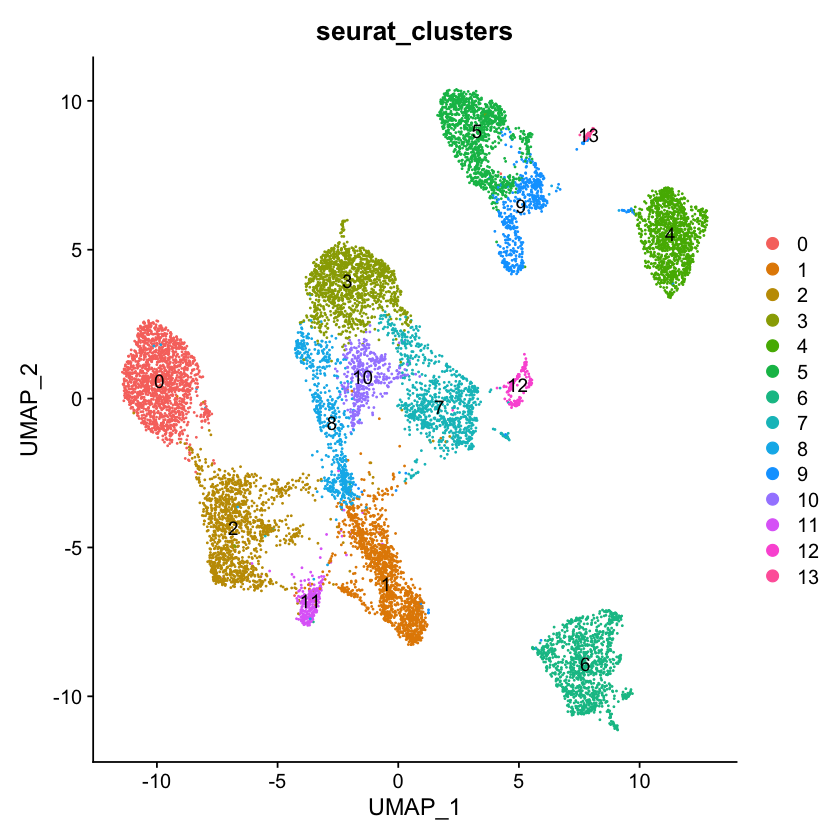

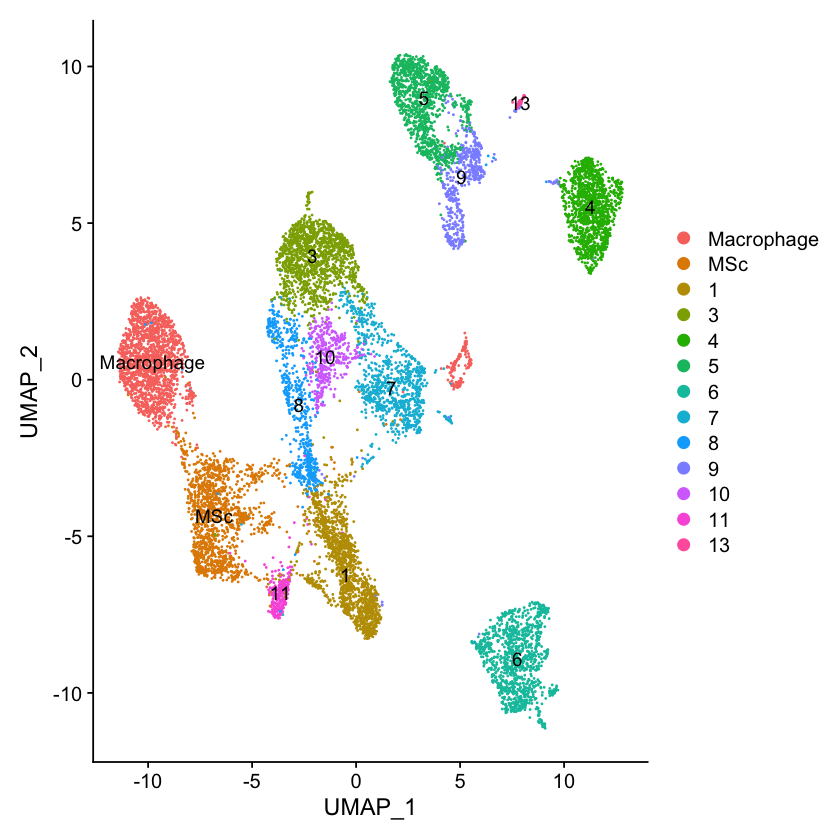

In [48]:
scRNA_harmony.1 <- RenameIdents(scRNA_harmony, 
                                "12" = "Macrophage", 
                                "0"="Macrophage", 
                                "2"="MSc")
DimPlot(scRNA_harmony.1, label = T, group.by = "seurat_clusters")
DimPlot(scRNA_harmony.1, label = T)
scRNA_harmony.1@meta.data$celltype=scRNA_harmony.1@active.ident
